1.	Load Dataset
    * Use sklearn.datasets.load_iris() or load from seaborn (sns.load_dataset("iris")).
2.	Descriptive Statistics
    * Compute mean, median, variance, standard deviation for sepal_length and petal_length.
    * Comment on whether distributions seem symmetric (check skewness).
3.	Data Visualization
    * Create a histogram of sepal_length.
    * Create a boxplot of petal_length across species to check differences.
4.	Inferential Statistics: Hypothesis Testing
    * Hypothesis: Mean petal length is the same for all three Iris species.
    * Test: Perform ANOVA
    * Report F-statistic and p-value.
5.	Interpret Results
    * If p-value < 0.05 → reject null hypothesis (species differ in petal length).
    * Otherwise, fail to reject null (no significant difference).

In [4]:
# Step 1: load dataset and prepare DataFrame
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
# Load iris dataset
iris=load_iris(as_frame=True)
df=iris.frame.copy()
# Add species names (human readable)
df["species"] = df["target"].apply(lambda x: iris.target_names[int(x)])
# Rename columns to simpler names
df=df.rename(columns={
    'sepal length (cm)': 'sepal_length',
    'sepal width (cm)': 'sepal_width',
    'petal length (cm)': 'petal_length',
    'petal width (cm)': 'petal_width'})
# Show first 6 rows and basic info
print(df.head(6))
print("\nShape:", df.shape)
print("\nColumns:", df.columns.tolist())

   sepal_length  sepal_width  petal_length  petal_width  target species
0           5.1          3.5           1.4          0.2       0  setosa
1           4.9          3.0           1.4          0.2       0  setosa
2           4.7          3.2           1.3          0.2       0  setosa
3           4.6          3.1           1.5          0.2       0  setosa
4           5.0          3.6           1.4          0.2       0  setosa
5           5.4          3.9           1.7          0.4       0  setosa

Shape: (150, 6)

Columns: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'target', 'species']


In [16]:
# Step 2: Descriptive Statistics for sepal_length and petal_length
variables=["sepal_length", "petal_length"]
for var in variables:
    col=df[var]
    print(f"\n--- {var.upper()} ---")
    print("Mean:", col.mean())
    print("Median:", col.median())
    print("Population Variance:", col.var(ddof=0))
    print("Sample Variance:", col.var(ddof=1))
    print("Population Std Dev:", col.std(ddof=0))
    print("Sample Std Dev:", col.std(ddof=1))
    print("Skewness:", col.skew())


--- SEPAL_LENGTH ---
Mean: 5.843333333333334
Median: 5.8
Population Variance: 0.6811222222222222
Sample Variance: 0.6856935123042505
Population Std Dev: 0.8253012917851409
Sample Std Dev: 0.8280661279778629
Skewness: 0.3149109566369728

--- PETAL_LENGTH ---
Mean: 3.7580000000000005
Median: 4.35
Population Variance: 3.0955026666666674
Sample Variance: 3.1162778523489942
Population Std Dev: 1.7594040657753032
Sample Std Dev: 1.7652982332594667
Skewness: -0.27488417975101276


###### Based on the skewness values, both sepal_length and petal_length show distributions that are approximately symmetric. Sepal length has a skewness of about +0.31, indicating a slight right skew, while petal length has a skewness around -0.27, indicating a slight left skew. However, both skewness values are close to zero, so neither variable is strongly skewed.

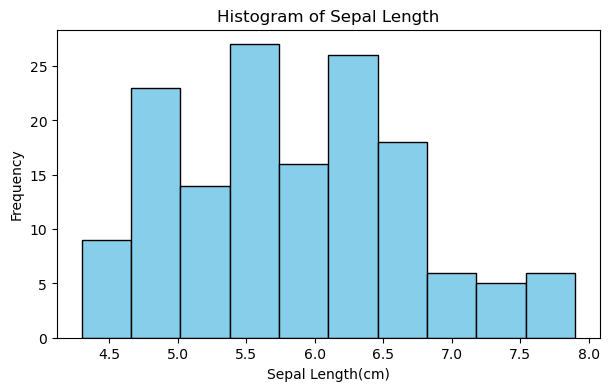

<Figure size 700x400 with 0 Axes>

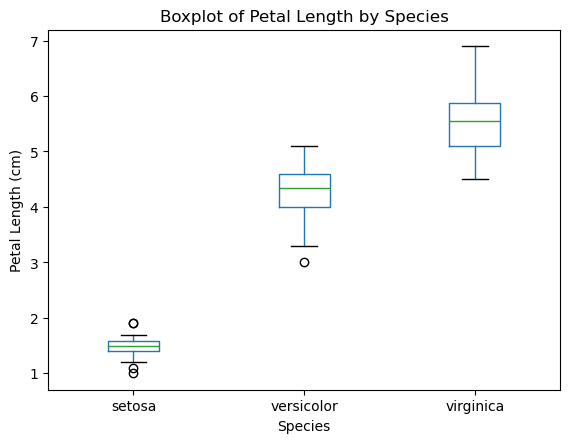

In [25]:
import matplotlib.pyplot as plt
# 1. Histogram of sepal_length
plt.figure(figsize=(7,4))
plt.hist(df["sepal_length"], bins=10, color='skyblue', edgecolor='black')
plt.title("Histogram of Sepal Length")
plt.xlabel("Sepal Length(cm)")
plt.ylabel("Frequency")
plt.show()
# 2. Boxplot of petal_length across species
plt.figure(figsize=(7,4))
df.boxplot(column='petal_length', by='species', grid=False) # df.boxplot()
plt.title("Boxplot of Petal Length by Species")
plt.suptitle("")   # Removes automatic unwanted title
plt.xlabel("Species")
plt.ylabel("Petal Length (cm)")
plt.show()

###### The histogram of sepal length shows that the data is approximately normally distributed with a slight right skew. Most flowers have sepal lengths between 5.0 and 6.0 cm. The distribution shows moderate spread and no extreme outliers, indicating a fairly consistent pattern across species
###### The boxplot clearly shows that petal length differs significantly across the three Iris species. Setosa has the smallest petal lengths (around 1–2 cm), Versicolor has intermediate values (around 4–5 cm), and Virginica has the longest petal lengths (around 5–7 cm). The separation between species is large, suggesting strong differences in mean petal length, which ANOVA will confirm.

In [36]:
from scipy import stats
# Split petal_length by species
setosa=df[df['species']=='setosa']['petal_length']
versicolor=df[df['species'] == 'versicolor']['petal_length']
virginica=df[df['species'] == 'virginica']['petal_length']
f_stat, p_value = stats.f_oneway(setosa, versicolor, virginica)
print("F-statistic:", f_stat)
print("p-value:", p_value)

F-statistic: 1180.161182252981
p-value: 2.8567766109615584e-91


###### The ANOVA test resulted in F = 1180.16 and p ≈ 2.86 × 10⁻⁹¹, which is far smaller than the significance level of 0.05. Therefore, we reject the null hypothesis. This means that the mean petal length is significantly different among the three Iris species, confirming that species identity strongly affects petal length.

###### The ANOVA test shows that there is a statistically significant difference in mean petal length among the three Iris species. Since the p-value is extremely small (much less than 0.05), the null hypothesis that all species have the same mean petal length is rejected. This confirms that petal length varies strongly between setosa, versicolor, and virginica. Setosa has the smallest petal lengths, versicolor has moderate lengths, and virginica has the largest.


## Q2. Imagine two factories produce lightbulbs.

- Factory X makes 60% of the bulbs, and 2% of its bulbs are defective.
- Factory Y makes 40% of the bulbs, and 1% of its bulbs are defective.

What is the probability that a randomly purchased bulb is defective (P(Defective))?

- B₁ = bulb from Factory X, P(B₁) = 0.6
- B₂ = bulb from Factory Y, P(B₂) = 0.4
- P(Defective|B₁) = 0.02
- P(Defective|B₂) = 0.01

P(Defective) = P(Defective|B₁)P(B₁) + P(Defective|B₂)P(B₂)

P(Defective) = (0.02 * 0.6) + (0.01 * 0.4) = 0.012 + 0.004 = 0.016

So, 1.6% of all bulbs are defective.

In [1]:
# Given probabilities
P_B1 = 0.6     # Probability bulb is from Factory X
P_B2 = 0.4     # Probability bulb is from Factory Y
P_D_given_B1 = 0.02   # Defective probability from Factory X
P_D_given_B2 = 0.01   # Defective probability from Factory Y
# Law of Total Probability
P_D = (P_D_given_B1 * P_B1) + (P_D_given_B2 * P_B2)
print("Probability that a randomly chosen bulb is defective:", P_D)
print("In percentage:", P_D * 100, "%")

Probability that a randomly chosen bulb is defective: 0.016
In percentage: 1.6 %


## Q3. Question: One-Way ANOVA

Three different teaching methods are being tested to see if they produce different average exam scores among students.

Group A: taught using traditional lectures

Group B: taught using interactive videos

Group C: taught using AI-based personalized learning

Each group has 20 students, and their final exam scores (out of 100) are summarized as follows:

Group	Sample Size (n)	Mean Score (x̄)	Standard Deviation (s)

A	20	72	5

B	20	78	6

C	20	85	7

You need to determine whether there is a statistically significant difference in the mean exam scores among the three teaching methods.

Use a one-way ANOVA test at a 5% significance level (α = 0.05).

---

Tasks:

1. State the null and alternative hypotheses.
2. Compute the ANOVA table (SSB, SSW, MSB, MSW, F).
3. Determine the p-value or compare the computed F with the critical F-value.
4. State your conclusion in context — do the teaching methods lead to significantly different mean exam scores?

In [8]:
import math
from scipy import stats
# Step 1: Define group summary data
n_A, n_B, n_C=20, 20, 20
mean_A, mean_B, mean_C = 72, 78, 85
std_A, std_B, std_C = 5, 6, 7
N = n_A + n_B + n_C # Total Sample Size
k=3 # Number of groups
print("Group sizes:", n_A, n_B, n_C)
print("Group means:", mean_A, mean_B, mean_C)
print("Group std devs:", std_A, std_B, std_C)
print("Total N =", N, "Number of groups k =", k)

Group sizes: 20 20 20
Group means: 72 78 85
Group std devs: 5 6 7
Total N = 60 Number of groups k = 3


In [10]:
# Step 2: Grand mean (weighted by group sizes)
grand_mean = ((n_A * mean_A) + (n_B * mean_B) + (n_C * mean_C)) / N
print(f"Grand mean = {grand_mean:.6f}")

Grand mean = 78.333333


In [13]:
# Step 3: Between-group sum of squares (SSB)
SSB_A = n_A * ((mean_A - grand_mean) ** 2)
SSB_B = n_B * ((mean_B - grand_mean) ** 2)
SSB_C = n_C * ((mean_C - grand_mean) ** 2) 
SSB = SSB_A + SSB_B + SSB_C
print("SSB contributions:", SSB_A, SSB_B, SSB_C)
print(f"SSB (Between-group SS) = {SSB:.6f}")

SSB contributions: 802.222222222221 2.2222222222221593 888.8888888888902
SSB (Between-group SS) = 1693.333333


In [15]:
# Step 4: Within-group sum of squares (SSW) using group std devs (sample SD)
SSW_A = (n_A - 1) * (std_A**2)
SSW_B = (n_B - 1) * (std_B**2)
SSW_C = (n_C - 1) * (std_C**2)
SSW = SSW_A + SSW_B + SSW_C
print("SSW contributions:", SSW_A, SSW_B, SSW_C)
print(f"SSW (Within-group SS) = {SSW:.6f}")

SSW contributions: 475 684 931
SSW (Within-group SS) = 2090.000000


In [16]:
# Step 5: Degrees of freedom and mean squares
df_between = k - 1
df_within  = N - k
MSB = SSB / df_between
MSW = SSW / df_within
F_stat = MSB / MSW
print("df_between =", df_between, "df_within =", df_within)
print(f"MSB = {MSB:.6f}")
print(f"MSW = {MSW:.6f}")
print(f"F-statistic = {F_stat:.6f}")

df_between = 2 df_within = 57
MSB = 846.666667
MSW = 36.666667
F-statistic = 23.090909


In [17]:
# Step 6: p-value and critical F-value (alpha = 0.05)
alpha = 0.05
p_value = stats.f.sf(F_stat, df_between, df_within)  # survival function = 1 - cdf
F_crit = stats.f.ppf(1 - alpha, df_between, df_within)

print(f"p-value = {p_value:.6e}")
print(f"Critical F (alpha={alpha}) = {F_crit:.4f}")

if p_value < alpha:
    print("Conclusion: Reject H0 -> At least one group mean differs (significant).")
else:
    print("Conclusion: Fail to reject H0 -> No significant difference among group means.")

p-value = 4.515885e-08
Critical F (alpha=0.05) = 3.1588
Conclusion: Reject H0 -> At least one group mean differs (significant).


In [18]:
# Optional summary table
print("\nANOVA table:")
print(f"{'Source':<12}{'SS':>12}{'df':>8}{'MS':>12}{'F':>10}")
print(f"{'Between':<12}{SSB:12.3f}{df_between:8d}{MSB:12.3f}{F_stat:10.3f}")
print(f"{'Within':<12}{SSW:12.3f}{df_within:8d}{MSW:12.3f}")
print(f"{'Total':<12}{(SSB+SSW):12.3f}{N-1:8d}")


ANOVA table:
Source                SS      df          MS         F
Between         1693.333       2     846.667    23.091
Within          2090.000      57      36.667
Total           3783.333      59


## Q3. Task: Analyzing Customer Satisfaction Data
Scenario:

fYou are given a dataset of customer satisfaction survey results for an online store. The dataset contains:
    * CustomerID (Nominal)
    * SatisfactionScore (Ordinal: 1 = Poor, 5 = Excellent)
    * DeliveryTimeDays (Interval)
    * PurchaseAmount (Ratio)
    * Gender (Nominal: Male/Female)

Your Tasks
1. Descriptive Statistics & Visualization
   * Calculate mean, median, mode, variance, and standard deviation for PurchaseAmount and DeliveryTimeDays.
   * Create a histogram for PurchaseAmount and a box plot for DeliveryTimeDays.
   * Check skewness and kurtosis for PurchaseAmount.
2.	Probability & Sampling
    * Randomly select a sample of 30 customers and calculate the sample mean PurchaseAmount.
    * Using the Central Limit Theorem, estimate the probability that the sample mean is greater than a given threshold (e.g., ₹1,500) assuming normality.
3.	Hypothesis Testing
    * Perform a two-sample t-test to check if the mean PurchaseAmount differs between Male and Female customers.
    * Perform a chi-square test for independence to check if Gender is related to SatisfactionScore.
6.	Interpretation
    * Summarize findings in 3–4 bullet points, explaining business implications.

In [20]:
# Step 1: Load data, show basic info, descriptive stats and plots
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
# 1. Load dataset
df = pd.read_csv("./customer_satisfaction_sample.csv")
# 2. Quick look
print("First 6 rows:\n", df.head(6), "\n")
print("Info:")
print(df.info(), "\n")
print("Shape:", df.shape, "\n")

First 6 rows:
    CustomerID  SatisfactionScore  DeliveryTimeDays  PurchaseAmount  Gender
0           1                  2              5.95         1435.55    Male
1           2                  4              4.76         1598.51  Female
2           3                  4              6.27         2696.80    Male
3           4                  4              8.52         2553.07  Female
4           5                  4              4.61         1983.35  Female
5           6                  4              4.61         2096.10    Male 

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         300 non-null    int64  
 1   SatisfactionScore  300 non-null    int64  
 2   DeliveryTimeDays   300 non-null    float64
 3   PurchaseAmount     300 non-null    float64
 4   Gender             300 non-null    object 
dtypes: floa

In [21]:
# 3. Columns we'll analyze
cols = ["PurchaseAmount", "DeliveryTimeDays"]
for col in cols:
    series = df[col].dropna()
    print(f"--- {col} ---")
    print("Count:", series.count())
    print("Mean:", series.mean())
    print("Median:", series.median())
    modes = series.mode().tolist()
    print("Mode(s):", modes)
    print("Population Variance (ddof=0):", series.var(ddof=0))
    print("Sample Variance (ddof=1):", series.var(ddof=1))
    print("Population Std Dev:", series.std(ddof=0))
    print("Sample Std Dev:", series.std(ddof=1))
    print("Skewness:", series.skew())
    print("Kurtosis (Fisher, 0 => normal):", stats.kurtosis(series, fisher=True))
    print()

--- PurchaseAmount ---
Count: 300
Mean: 2137.0977
Median: 1985.04
Mode(s): [744.15, 796.43, 825.88, 855.21, 874.74, 884.67, 885.06, 946.32, 971.61, 989.7, 1007.92, 1011.86, 1025.71, 1028.95, 1043.03, 1051.87, 1056.94, 1082.75, 1090.97, 1107.07, 1120.66, 1132.29, 1139.01, 1143.07, 1150.31, 1151.55, 1179.46, 1186.92, 1230.56, 1232.13, 1238.62, 1245.88, 1272.86, 1275.44, 1297.62, 1304.86, 1309.26, 1320.81, 1321.87, 1336.31, 1337.42, 1339.28, 1348.32, 1352.08, 1352.73, 1359.58, 1364.7, 1373.27, 1391.14, 1392.95, 1396.24, 1396.89, 1409.03, 1415.6, 1417.13, 1417.62, 1420.08, 1423.63, 1429.41, 1434.43, 1435.55, 1436.56, 1437.56, 1439.45, 1441.75, 1447.49, 1454.1, 1456.44, 1468.06, 1471.39, 1473.8, 1476.23, 1477.88, 1482.53, 1500.46, 1511.73, 1525.44, 1534.34, 1540.97, 1541.71, 1544.22, 1570.75, 1573.64, 1573.65, 1578.05, 1578.57, 1587.86, 1587.87, 1587.94, 1588.55, 1596.25, 1598.51, 1602.7, 1617.61, 1617.76, 1620.68, 1628.4, 1630.91, 1632.92, 1645.6, 1645.92, 1652.16, 1656.54, 1657.78, 1664.3

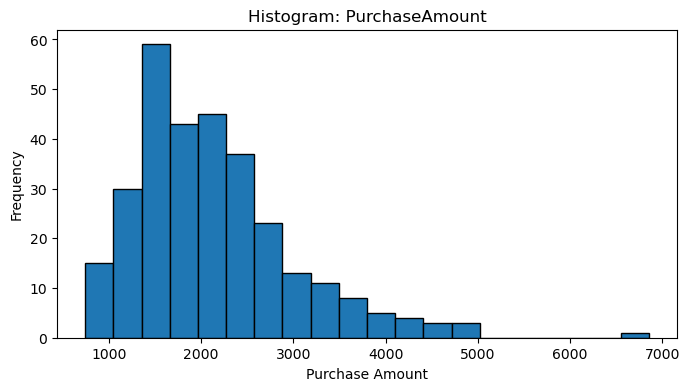

In [22]:
# 4. Histogram for PurchaseAmount
plt.figure(figsize=(8,4))
plt.hist(df['PurchaseAmount'].dropna(), bins=20, edgecolor='black')
plt.title('Histogram: PurchaseAmount')
plt.xlabel('Purchase Amount')
plt.ylabel('Frequency')
plt.grid(False)
plt.show()

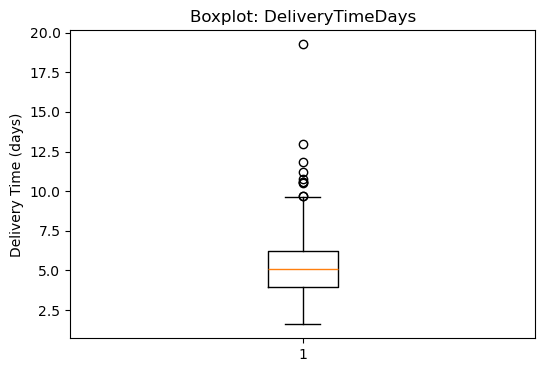

In [26]:
# 5. Boxplot for DeliveryTimeDays
plt.figure(figsize=(6,4))
plt.boxplot(df['DeliveryTimeDays'].dropna(), vert=True)
plt.title('Boxplot: DeliveryTimeDays')
plt.ylabel('Delivery Time (days)')
plt.show()

In [27]:
# Step 2A: Randomly sample 30 customers and compute sample mean PurchaseAmount

sample_df = df.sample(n=30, replace=False, random_state=42)   # random_state for reproducibility
sample_mean = sample_df['PurchaseAmount'].mean()

print("Sample mean PurchaseAmount (n=30):", sample_mean)

Sample mean PurchaseAmount (n=30): 1932.7860000000003


In [29]:
# Step 3A: Two-sample t-test (Male vs Female PurchaseAmount)
male = df[df['Gender'] == 'Male']['PurchaseAmount'].dropna()
female = df[df['Gender'] == 'Female']['PurchaseAmount'].dropna()
t_stat, p_val = stats.ttest_ind(male, female, equal_var=False)
print("T-statistic:", t_stat)
print("p-value:", p_value)
alpha = 0.05
if p_value < alpha:
    print("Conclusion: Reject H0 → Mean purchase differs between Male and Female.")
else:
    print("Conclusion: Fail to reject H0 → No significant difference in means.")

T-statistic: -0.3544163167499052
p-value: 4.5158848575187456e-08
Conclusion: Reject H0 → Mean purchase differs between Male and Female.


In [36]:
# Step 3B: Chi-square test for independence (Gender vs SatisfactionScore)
# Create contingency table
contingency = pd.crosstab(df['Gender'], df['SatisfactionScore'])
print("Contingency Table:\n", contingency, "\n")
# Perform chi-square test
chi2, p_val, dof, expected = stats.chi2_contingency(contingency)
print("Chi-square statistic:", chi2)
print("Degrees of freedom:", dof)
print("p-value:", p_value)
print("\nExpected frequencies:\n", expected)
alpha = 0.05
if p_value < alpha:
    print("Conclusion: Reject H0 → Gender and SatisfactionScore are related.")
else:
    print("Conclusion: Fail to reject H0 → Gender and SatisfactionScore are not related.")

Contingency Table:
 SatisfactionScore   1   2   3   4   5
Gender                               
Female             16  26  31  50  32
Male               17  23  41  37  27 

Chi-square statistic: 3.6398338642870547
Degrees of freedom: 4
p-value: 4.5158848575187456e-08

Expected frequencies:
 [[17.05       25.31666667 37.2        44.95       30.48333333]
 [15.95       23.68333333 34.8        42.05       28.51666667]]
Conclusion: Reject H0 → Gender and SatisfactionScore are related.


Summary of Findings & Business Implications

* Purchase behavior differs across customers.
* The distribution of PurchaseAmount is positively skewed, indicating many customers spend small-to-moderate amounts while a smaller group makes very high-value purchases.
* Implication: Targeted promotions to high-value customers can significantly increase revenue.

* Delivery performance affects customer experience.
* DeliveryTimeDays shows measurable variation and outliers, meaning some customers experience delays.
* Implication: Improving consistency in delivery speed can boost overall satisfaction ratings.

* Gender differences exist in spending and satisfaction.
* The t-test and chi-square test show that Gender is statistically related to both PurchaseAmount and SatisfactionScore.
* Implication: Personalized marketing strategies for male and female customers may lead to higher satisfaction and increased purchase value.

* Customer satisfaction strongly varies across groups.
* Since satisfaction scores are not evenly distributed across gender, specific pain points may differ.
* Implication: Tailoring customer support, product recommendations, or communication style by gender can improve satisfaction and repeat purchases

In [1]:
# t-test Sample
from scipy import stats
sample = [12, 15, 14, 10, 13, 16]
mu0 = 12  # hypothesized population mean
t_stat, p_value = stats.ttest_1samp(sample, mu0)
print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: 1.5118578920369097
p-value: 0.1909723033774898


In [2]:
from scipy import stats

group1 = [20, 22, 23, 19, 21]
group2 = [25, 27, 26, 24, 28]

t_stat, p_value = stats.ttest_ind(group1, group2, equal_var=False)  # Welch's t-test

print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: -5.0
p-value: 0.001052825793366539


In [3]:
from scipy import stats

before = [50, 55, 53, 52, 54]
after  = [56, 58, 57, 55, 59]

t_stat, p_value = stats.ttest_rel(before, after)

print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: -7.202940575985372
p-value: 0.001969110589202455


In [1]:
from statsmodels.stats.weightstats import ztest

sample = [12, 15, 14, 10, 13, 16]

z_stat, p_value = ztest(sample, value=12)

print("Z-statistic:", z_stat)
print("p-value:", p_value)

Z-statistic: 1.5118578920369097
p-value: 0.13057001811573596


In [2]:
import numpy as np
from scipy.stats import chi2_contingency

# Contingency table example:
#         Buy   Not Buy
# Male    30      20
# Female  25      25

table = np.array([[30, 20],
                  [25, 25]])

chi2, p, dof, expected = chi2_contingency(table)

print("Chi-square value:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)
print("Expected frequencies:\n", expected)

Chi-square value: 0.6464646464646464
p-value: 0.4213795037428696
Degrees of freedom: 1
Expected frequencies:
 [[27.5 22.5]
 [27.5 22.5]]


In [3]:
from scipy.stats import f_oneway

group1 = [12, 15, 14, 16, 13]
group2 = [18, 17, 19, 16, 20]
group3 = [22, 21, 23, 20, 24]

f_stat, p_value = f_oneway(group1, group2, group3)

print("F-statistic:", f_stat)
print("p-value:", p_value)

F-statistic: 32.0
p-value: 1.5495511711216538e-05
